In [50]:
library(tidyverse)
library(vroom)
library(data.table)
library(future.apply)

####### Systematic processing. ########
out_dir <- "/mnt/dawnccle2/processed_data/reprocess_250221/count_normalized_satmutv1_dawn/"
# Create outdir.
dir.create(out_dir, showWarnings = FALSE)


# First we look at all the samples that are available. 
input_dir1 <- "/mnt/dawnccle2/processed_data/satmutv1_dawn/"

# Get all full filenames in all the input dirs. 
cellline_filenames1 <- list.files(path = input_dir1, pattern = "umi_dedup_fine_grained_idx.csv$", full.names = TRUE)

# Make a df of these filenames.
cellline_paths <- data.frame(filename = c(cellline_filenames1))
cellline_paths <- cellline_paths %>% 
  mutate(basename = basename(filename)) %>%
  mutate(sample = str_extract(basename(filename), ".+(?=_umi_dedup)")) %>%
  mutate(condition = str_extract(sample, "^.+(?=-rep\\d)")) %>% 
  # Strip satmutv2_ from the condition.
  mutate(condition = str_replace(condition, "satmut_", "")) %>%
  mutate(rep_old = str_extract(basename(filename), "rep\\d")) %>%
  mutate(rep_new = rep_old) %>% 
  mutate(sample_new = paste0(condition, "-", rep_new))



In [11]:
cellline_paths

filename,basename,sample,condition,rep_old,rep_new,sample_new
<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
/mnt/dawnccle2/processed_data/satmutv1_dawn//satmut_8MGBA-rep1_S76_umi_dedup_fine_grained_idx.csv,satmut_8MGBA-rep1_S76_umi_dedup_fine_grained_idx.csv,satmut_8MGBA-rep1_S76,8MGBA,rep1,rep1,8MGBA-rep1
/mnt/dawnccle2/processed_data/satmutv1_dawn//satmut_8MGBA-rep1_test_S76_umi_dedup_fine_grained_idx.csv,satmut_8MGBA-rep1_test_S76_umi_dedup_fine_grained_idx.csv,satmut_8MGBA-rep1_test_S76,8MGBA,rep1,rep1,8MGBA-rep1
/mnt/dawnccle2/processed_data/satmutv1_dawn//satmut_8MGBA-rep2_S77_umi_dedup_fine_grained_idx.csv,satmut_8MGBA-rep2_S77_umi_dedup_fine_grained_idx.csv,satmut_8MGBA-rep2_S77,8MGBA,rep2,rep2,8MGBA-rep2
/mnt/dawnccle2/processed_data/satmutv1_dawn//satmut_8MGBA-rep3_S78_umi_dedup_fine_grained_idx.csv,satmut_8MGBA-rep3_S78_umi_dedup_fine_grained_idx.csv,satmut_8MGBA-rep3_S78,8MGBA,rep3,rep3,8MGBA-rep3
/mnt/dawnccle2/processed_data/satmutv1_dawn//satmut_HCC1428-rep1_S94_umi_dedup_fine_grained_idx.csv,satmut_HCC1428-rep1_S94_umi_dedup_fine_grained_idx.csv,satmut_HCC1428-rep1_S94,HCC1428,rep1,rep1,HCC1428-rep1
/mnt/dawnccle2/processed_data/satmutv1_dawn//satmut_HCC1428-rep2_S95_umi_dedup_fine_grained_idx.csv,satmut_HCC1428-rep2_S95_umi_dedup_fine_grained_idx.csv,satmut_HCC1428-rep2_S95,HCC1428,rep2,rep2,HCC1428-rep2
/mnt/dawnccle2/processed_data/satmutv1_dawn//satmut_HCC1428-rep3_S96_umi_dedup_fine_grained_idx.csv,satmut_HCC1428-rep3_S96_umi_dedup_fine_grained_idx.csv,satmut_HCC1428-rep3_S96,HCC1428,rep3,rep3,HCC1428-rep3
/mnt/dawnccle2/processed_data/satmutv1_dawn//satmut_HCC38-rep1_S91_umi_dedup_fine_grained_idx.csv,satmut_HCC38-rep1_S91_umi_dedup_fine_grained_idx.csv,satmut_HCC38-rep1_S91,HCC38,rep1,rep1,HCC38-rep1
/mnt/dawnccle2/processed_data/satmutv1_dawn//satmut_HCC38-rep2_S92_umi_dedup_fine_grained_idx.csv,satmut_HCC38-rep2_S92_umi_dedup_fine_grained_idx.csv,satmut_HCC38-rep2_S92,HCC38,rep2,rep2,HCC38-rep2


In [51]:
# Extract all metrics and append to cellline_paths
metrics_list <- lapply(1:nrow(cellline_paths), function(i) {
  filename_full <- cellline_paths$filename[i]
  sample_name <- cellline_paths$sample[i]
  filename_dir <- dirname(filename_full)
  stats_log_path <- file.path(filename_dir, paste0(sample_name, "_stats_log_fine_grained_idx.txt"))
  
  if (file.exists(stats_log_path)) {
    stats_log <- read_csv(stats_log_path, col_names = FALSE)
    colnames(stats_log) <- c("metric", "count")
    
    # Convert metrics to a named list
    metric_values <- as.list(setNames(stats_log$count, stats_log$metric))
    return(metric_values)
  } else {
    return(NULL)
  }
})

# Combine metrics with cellline_paths
metrics_df <- bind_rows(metrics_list) %>%
  mutate_all(as.character)  # Ensure consistent data type

cellline_paths <- bind_cols(cellline_paths, metrics_df)

# Filter out samples that have < 1M aligned reads.
cellline_paths_filtered <- cellline_paths %>% 
  mutate(total_aligned_reads = as.integer(total_aligned_reads)) %>% 
  filter(total_aligned_reads >= 1e6) 

# Write this metadata to file.
write_csv(cellline_paths_filtered, "/mnt/dawnccle2/melange/process_fastq_250221/10_satmutv2/cellline_sample_metadata_satmutv1.csv")


Rows: 13 Columns: 2
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (1): X1
dbl (1): X2

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.
Rows: 13 Columns: 2
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (1): X1
dbl (1): X2

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.
Rows: 13 Columns: 2
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (1): X1
dbl (1): X2

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.
Rows: 13 Columns: 2
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","

In [ ]:
# Parallel version of merge_offsets_to_ref.
merge_offsets_to_ref_parallel <- function(df, workers = 64) {
  plan(multisession, workers = workers)

  # Preprocess and split
  df_sep <- df %>%
    separate(offset, into = c("upstream_offset", "downstream_offset", "const_offset"), sep = ":", remove = FALSE) %>%
    mutate(index_full = paste0(index, "_", offset_initial, "_", design)) %>% 
    mutate(across(c(upstream_offset, downstream_offset, const_offset), as.integer)) %>%
    as.data.table()

  cat("done separating\n")

  # Split by index (parallelizable units)
  df_list <- split(df_sep, by = "index_full")
  # Greedy merge function (same as before, per index)
  greedy_merge_index <- function(df_idx) {
    setorder(df_idx, -count)
    merged <- data.table()

    while (nrow(df_idx) > 0) {
      anchor <- df_idx[1]
      u0 <- anchor$upstream_offset
      d0 <- anchor$downstream_offset
      c0 <- anchor$const_offset

      neighbors <- df_idx[
        upstream_offset %between% c(u0 - 1, u0 + 1) &
        downstream_offset %between% c(d0 - 1, d0 + 1)
      ]

      anchor$count <- sum(neighbors$count)
      merged <- rbind(merged, anchor, use.names = TRUE)
      df_idx <- fsetdiff(df_idx, neighbors)
    }

    return(merged)
  }

  # Run in parallel across indices
  results <- future_lapply(df_list, greedy_merge_index)

  # Combine and clean
  out <- rbindlist(results)
  out[, c("upstream_offset", "downstream_offset", "const_offset", "index_full") := NULL]
  return(out[])
}

# Get all unique sample_new names.
unique_samples <- cellline_paths_filtered %>% group_by(sample_new) %>% summarise(n=n()) %>% ungroup() 
unique_sample_names <- unique(cellline_paths_filtered$sample_new)

# merge_offsets_to_ref_parallel(tmp_included_sequences_only)


In [14]:
unique_sample_names


[1] "8MGBA-rep1"   "8MGBA-rep2"   "8MGBA-rep3"   "HCC1428-rep1" "HCC1428-rep2"
 [6] "HCC1428-rep3" "HCC38-rep1"   "HCC38-rep2"   "HCC38-rep3"   "JHH6-rep2"   
[11] "JHH6-rep3"    "Kelly-rep1"   "Kelly-rep2"   "Kelly-rep3"   "KMRC20-rep1" 
[16] "KMRC20-rep3"  "MCF7-rep1"    "MCF7-rep2"    "MCF7-rep3"    "T47D-rep1"   
[21] "T47D-rep2"    "T47D-rep3"

# Maile single base saturation mutagenesis files

In [22]:
# Also do for Maile files
merge_offsets_to_ref <- function(df){
  print("Merging offsets to ref")
  print(head(df))
  df_sep <- df %>% 
  ungroup() %>% 
  separate(offset, into = c("upstream_offset", "downstream_offset", "const_offset"), sep = ":", remove = FALSE) %>% 
  mutate(upstream_offset = as.integer(upstream_offset), downstream_offset = as.integer(downstream_offset), const_offset = as.integer(const_offset)) %>% 
  mutate(index_full = paste0(index, "_", location, "_", base))
  cat("done separating\n")
  unique_indices <- unique(df_sep$index_full)
  print(head(unique_indices))
  new_df <- data.frame()
  for (idx in unique_indices){
    df_tmp_idx <- df_sep %>% 
      filter(index_full == idx) %>% 
      arrange(desc(count))
    # cat("################## before merging dataframe for index:", idx, "\n")
    # print(df_tmp_idx, n = nrow(df_tmp_idx), width = Inf)
    new_df_tmp_idx <- data.frame()
    while (nrow(df_tmp_idx) > 0){
      max_offset_row <- df_tmp_idx %>% slice(1)
      max_offset_val_upstream <- max_offset_row$upstream_offset
      max_offset_val_downstream <- max_offset_row$downstream_offset
      # Get all possible offses for upstream_offset, downstream_offset. +/- 1.
      possible_offset_rows <- df_tmp_idx %>% 
      filter((upstream_offset == max_offset_val_upstream + 1 & downstream_offset == max_offset_val_downstream) |
             (upstream_offset == max_offset_val_upstream - 1 & downstream_offset == max_offset_val_downstream) |
             (upstream_offset == max_offset_val_upstream & downstream_offset == max_offset_val_downstream + 1) |
             (upstream_offset == max_offset_val_upstream & downstream_offset == max_offset_val_downstream - 1) |
             (upstream_offset == max_offset_val_upstream & downstream_offset == max_offset_val_downstream) |
             (upstream_offset == max_offset_val_upstream + 1 & downstream_offset == max_offset_val_downstream + 1) |
             (upstream_offset == max_offset_val_upstream + 1 & downstream_offset == max_offset_val_downstream - 1) |
             (upstream_offset == max_offset_val_upstream - 1 & downstream_offset == max_offset_val_downstream + 1) |
             (upstream_offset == max_offset_val_upstream - 1 & downstream_offset == max_offset_val_downstream - 1))
      # Merge the counts for these possible_offset_rows. And assign the count to the max_offset_row.
      merged_counts <- possible_offset_rows %>% pull(count) %>% sum()
      max_offset_row$count <- merged_counts
      # Remove the possible_offset_rows from df_tmp_idx. Need to be the exact pairs that are in possible_offset_rows.
      # Filter out the exact pairs that are in possible_offset_rows
      df_tmp_idx <- anti_join(df_tmp_idx, possible_offset_rows, 
                             by = c("upstream_offset", "downstream_offset", "const_offset"))
      # Add the max_offset_row to new_df_tmp_idx.
      new_df_tmp_idx <- bind_rows(new_df_tmp_idx, max_offset_row)
    }
    # cat("Final merged dataframe for index:", idx, "\n")
    #print(new_df_tmp_idx)
    new_df <- bind_rows(new_df, new_df_tmp_idx)
  }
  # Remove the upstream_offset, downstream_offset, const_offset columns.
  new_df <- new_df %>% select(-upstream_offset, -downstream_offset, -const_offset, -index_full)
  return(new_df)
}

for (sample_tmp in unique_sample_names){
  # Get all the filepaths with that sample name.
  sample_filepaths <- cellline_paths_filtered %>% filter(sample_new == sample_tmp) %>% pull(filename)
  tmp_out <- data.frame()
  for (filepath in sample_filepaths) {
    base::print(paste("Processing", filepath))
    # Get the parent folder name from the filepath. (not full path)
    parent_folder <- basename(dirname(filepath))
    # Get basename and strip _umi_dedup_fine_grained_idx.csv
    filename_basename <- basename(filepath) %>% str_extract(".+(?=_umi_dedup_fine_grained_idx.csv)")
    
    # Read in the tsv file.
    tmp <- vroom(filepath, id = "filename", delim = ",")
    
    # Get chimeric rate from the metadata table. 
    chimeric_rate <- cellline_paths_filtered %>% 
      filter(filename == filepath) %>% 
      pull(perc_chimera_reads)
    base::print(paste("chimeric_rate:", chimeric_rate))
    
    print(head(tmp))
    # Separate the "index" column into id, mode, offset, insert_size based on __ separator.
    tmp_to_ref <- tmp %>% 
      separate(index, into = c("index_initial_tmp", "mode", "offset" ,"insert_size"), sep = "__", remove = TRUE) %>% 
      separate(index_initial_tmp, into = c("index", "location", "base"), sep = "_", remove = FALSE) %>% 
      select(-insert_size)
    
    # Split into included (need offset merging), and everything else (need adjustment).
    # We just directly adjust the counts for non-included as count_scaled = count * (1 - chimeric_rate).
    tmp_included_sequences_only <- tmp_to_ref %>% filter(mode == "INCLUDED") 
    tmp_included_merged_offsets <- merge_offsets_to_ref(tmp_included_sequences_only) %>% mutate(count_scaled = count)
    # Normalize the non-included reads.  
    tmp_everything_else <- tmp_to_ref %>% filter(mode != "INCLUDED") %>% mutate(count_scaled = count)
    
    tmp_final <- bind_rows(tmp_included_merged_offsets, tmp_everything_else)

    tmp_out <- bind_rows(tmp_out, tmp_final) %>% 
                  group_by(filename, index_initial_tmp, index, location, base, mode, offset) %>% 
                  summarise(count = sum(count), count_scaled = sum(count_scaled)) %>% 
                  arrange(index_initial_tmp, offset)
  }
  
  # Write to outdir. 
  base::print(paste("Writing to", file.path(out_dir, paste0(sample_tmp, "_umi_dedup_normalized_satmutv1.tsv"))))
  fwrite(tmp_out, file.path(out_dir, paste0(sample_tmp, "_umi_dedup_normalized_satmutv1.tsv")))
}

[1] "Processing /mnt/dawnccle2/processed_data/satmutv1_dawn//satmut_8MGBA-rep1_S76_umi_dedup_fine_grained_idx.csv"


Rows: 53342 Columns: 3
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (1): index
dbl (1): count

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


[1] "chimeric_rate: 0.141514286942387"
# A tibble: 6 × 3
  filename                                                           index count
  <chr>                                                              <chr> <dbl>
1 /mnt/dawnccle2/processed_data/satmutv1_dawn//satmut_8MGBA-rep1_S7… ADCY…     1
2 /mnt/dawnccle2/processed_data/satmutv1_dawn//satmut_8MGBA-rep1_S7… ADCY…     2
3 /mnt/dawnccle2/processed_data/satmutv1_dawn//satmut_8MGBA-rep1_S7… ADCY…   314
4 /mnt/dawnccle2/processed_data/satmutv1_dawn//satmut_8MGBA-rep1_S7… ADCY…     6
5 /mnt/dawnccle2/processed_data/satmutv1_dawn//satmut_8MGBA-rep1_S7… ADCY…    35
6 /mnt/dawnccle2/processed_data/satmutv1_dawn//satmut_8MGBA-rep1_S7… ADCY…    19


Warning message:
“Expected 3 pieces. Missing pieces filled with `NA` in 175 rows [1, 2, 3, 4, 5,
6, 7, 1641, 1642, 1643, 1644, 1645, 1646, 1647, 1648, 1649, 1650, 1651, 1652,
1653, ...].”


[1] "Merging offsets to ref"
# A tibble: 6 × 8
  filename             index_initial_tmp index location base  mode  offset count
  <chr>                <chr>             <chr> <chr>    <chr> <chr> <chr>  <dbl>
1 /mnt/dawnccle2/proc… ADCY5             ADCY5 NA       NA    INCL… -1:0:0     1
2 /mnt/dawnccle2/proc… ADCY5             ADCY5 NA       NA    INCL… 0:0:0      2
3 /mnt/dawnccle2/proc… ADCY5             ADCY5 NA       NA    INCL… 0:0:0    314
4 /mnt/dawnccle2/proc… ADCY5             ADCY5 NA       NA    INCL… 0:0:0      6
5 /mnt/dawnccle2/proc… ADCY5_downstream… ADCY5 downstr… 10A   INCL… 0:0:0      5
6 /mnt/dawnccle2/proc… ADCY5_downstream… ADCY5 downstr… 10A   INCL… 0:0:0    136
done separating
[1] "ADCY5_NA_NA"          "ADCY5_downstream_10A" "ADCY5_downstream_10C"
[4] "ADCY5_downstream_10T" "ADCY5_downstream_11A" "ADCY5_downstream_11G"


...

[1] "chimeric_rate: 0.156775878673448"
# A tibble: 6 × 3
  filename                                                           index count
  <chr>                                                              <chr> <dbl>
1 /mnt/dawnccle2/processed_data/satmutv1_dawn//satmut_T47D-rep3_S81… ADCY…   332
2 /mnt/dawnccle2/processed_data/satmutv1_dawn//satmut_T47D-rep3_S81… ADCY…     3
3 /mnt/dawnccle2/processed_data/satmutv1_dawn//satmut_T47D-rep3_S81… ADCY…     1
4 /mnt/dawnccle2/processed_data/satmutv1_dawn//satmut_T47D-rep3_S81… ADCY…    58
5 /mnt/dawnccle2/processed_data/satmutv1_dawn//satmut_T47D-rep3_S81… ADCY…     3
6 /mnt/dawnccle2/processed_data/satmutv1_dawn//satmut_T47D-rep3_S81… ADCY…     4


Warning message:
“Expected 3 pieces. Missing pieces filled with `NA` in 158 rows [1, 2, 3, 4, 5,
6, 1479, 1480, 1481, 1482, 1483, 1484, 1485, 1486, 1487, 1488, 1489, 1490,
1491, 1492, ...].”


[1] "Merging offsets to ref"
# A tibble: 6 × 8
  filename             index_initial_tmp index location base  mode  offset count
  <chr>                <chr>             <chr> <chr>    <chr> <chr> <chr>  <dbl>
1 /mnt/dawnccle2/proc… ADCY5             ADCY5 NA       NA    INCL… 0:0:0    332
2 /mnt/dawnccle2/proc… ADCY5             ADCY5 NA       NA    INCL… 0:0:0      3
3 /mnt/dawnccle2/proc… ADCY5             ADCY5 NA       NA    INCL… 350:3…     1
4 /mnt/dawnccle2/proc… ADCY5_downstream… ADCY5 downstr… 10A   INCL… 0:0:0     10
5 /mnt/dawnccle2/proc… ADCY5_downstream… ADCY5 downstr… 10A   INCL… 0:0:0    151
6 /mnt/dawnccle2/proc… ADCY5_downstream… ADCY5 downstr… 10C   INCL… 0:0:0    173
done separating
[1] "ADCY5_NA_NA"          "ADCY5_downstream_10A" "ADCY5_downstream_10C"
[4] "ADCY5_downstream_10T" "ADCY5_downstream_11A" "ADCY5_downstream_11G"


`summarise()` has grouped output by 'filename', 'index_initial_tmp', 'index',
'location', 'base', 'mode'. You can override using the `.groups` argument.


[1] "Writing to /mnt/dawnccle2/processed_data/reprocess_250221/count_normalized_satmutv1_dawn//T47D-rep3_umi_dedup_normalized_satmutv1.tsv"


# Merge the samples into 1 file

In [26]:
# Merge samples into one file. 
library(tidyverse)
library(vroom)
library(data.table)

out_dir <- "/mnt/dawnccle2/processed_data/reprocess_250221/count_normalized_satmutv1_dawn/"
dir.create(out_dir, showWarnings = FALSE)

process_samples <- function(input_dir, sample_type, out_dir) {
  dir.create(out_dir, showWarnings = FALSE, recursive = TRUE)
  
  input_filenames <- list.files(path = input_dir, pattern = "umi_dedup_normalized_satmutv1.tsv$", full.names = TRUE)
  
  # Precompute sample and condition for each file
  file_metadata <- tibble(
    filename = input_filenames,
    sample = basename(input_filenames) %>% str_extract(".+(?=_umi_dedup_normalized_satmutv1.tsv)"),
    condition = str_extract(basename(input_filenames), "^.+(?=-rep\\d)")
  )
  
  # Read data and attach metadata
  all_files_df <- map_dfr(seq_along(file_metadata$filename), function(i) {
    df <- vroom(file_metadata$filename[i], delim = ",")
    df$sample <- file_metadata$sample[i]
    df$condition <- file_metadata$condition[i]
    df
  })
  
  print(paste("Writing to", file.path(out_dir, paste0(sample_type, "_all_samples_raw_counts_satmutv1.csv"))))
  fwrite(all_files_df, file.path(out_dir, paste0(sample_type, "_all_samples_raw_counts_satmutv1.csv")))
}

# Define input and output directories
input_output_mapping <- list(
  list(input_dir = "/mnt/dawnccle2/processed_data/reprocess_250221/count_normalized_satmutv1_dawn/", 
       sample_type = "satmutv1_dawn", 
       out_dir = "/mnt/dawnccle2/processed_data/reprocess_250221/count_normalized_satmutv1_dawn/")
)

# Process each sample type
walk(input_output_mapping, ~process_samples(.x$input_dir, .x$sample_type, .x$out_dir))

Rows: 38862 Columns: 9
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (7): filename, index_initial_tmp, index, location, base, mode, offset
dbl (2): count, count_scaled

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.
Rows: 40067 Columns: 9
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (7): filename, index_initial_tmp, index, location, base, mode, offset
dbl (2): count, count_scaled

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.
Rows: 37813 Columns: 9
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (7): filename, index_initial_tmp, index, location, base, mode, offset
dbl (2): count, count_scaled

ℹ Use `spec()` to retri

[1] "Writing to /mnt/dawnccle2/processed_data/reprocess_250221/count_normalized_satmutv1_dawn//satmutv1_dawn_all_samples_raw_counts_satmutv1.csv"


# Now analyze the data

`summarise()` has grouped output by 'sample', 'condition', 'index_offset',
'index', 'mode', 'offset', 'location'. You can override using the `.groups`
argument.


sample,condition,index_offset,index,mode,offset,location,base,count
<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<int>
8MGBA-rep1,8MGBA,ADCY5,ADCY5,INCLUDED,0:0:0,,,323
8MGBA-rep1,8MGBA,ADCY5,ADCY5,SKIPPED,0,,,35
8MGBA-rep1,8MGBA,ADCY5_downstream_10A,ADCY5,INCLUDED,0:0:0,downstream,10A,142
8MGBA-rep1,8MGBA,ADCY5_downstream_10A,ADCY5,SKIPPED,0,downstream,10A,7
8MGBA-rep1,8MGBA,ADCY5_downstream_10C,ADCY5,INCLUDED,0:-2:0,downstream,10C,2
8MGBA-rep1,8MGBA,ADCY5_downstream_10C,ADCY5,INCLUDED,0:0:0,downstream,10C,185


`summarise()` has grouped output by 'sample', 'condition', 'index_offset',
'index', 'mode', 'location'. You can override using the `.groups` argument.


sample,condition,index_offset,index,location,base,INCLUDED,SKIPPED,total_counts,PSI,base_loc
<chr>,<chr>,<chr>,<chr>,<fct>,<chr>,<int>,<int>,<int>,<dbl>,<dbl>
8MGBA-rep1,8MGBA,ADCY5_downstream_10A,ADCY5,downstream,10A,142,7,149,0.9530201,10
8MGBA-rep1,8MGBA,ADCY5_downstream_10C,ADCY5,downstream,10C,187,23,210,0.8904762,10
8MGBA-rep1,8MGBA,ADCY5_downstream_10T,ADCY5,downstream,10T,290,22,312,0.9294872,10
8MGBA-rep1,8MGBA,ADCY5_downstream_11A,ADCY5,downstream,11A,87,17,104,0.8365385,11
8MGBA-rep1,8MGBA,ADCY5_downstream_11G,ADCY5,downstream,11G,74,2,76,0.9736842,11
8MGBA-rep1,8MGBA,ADCY5_downstream_11T,ADCY5,downstream,11T,192,22,214,0.8971963,11


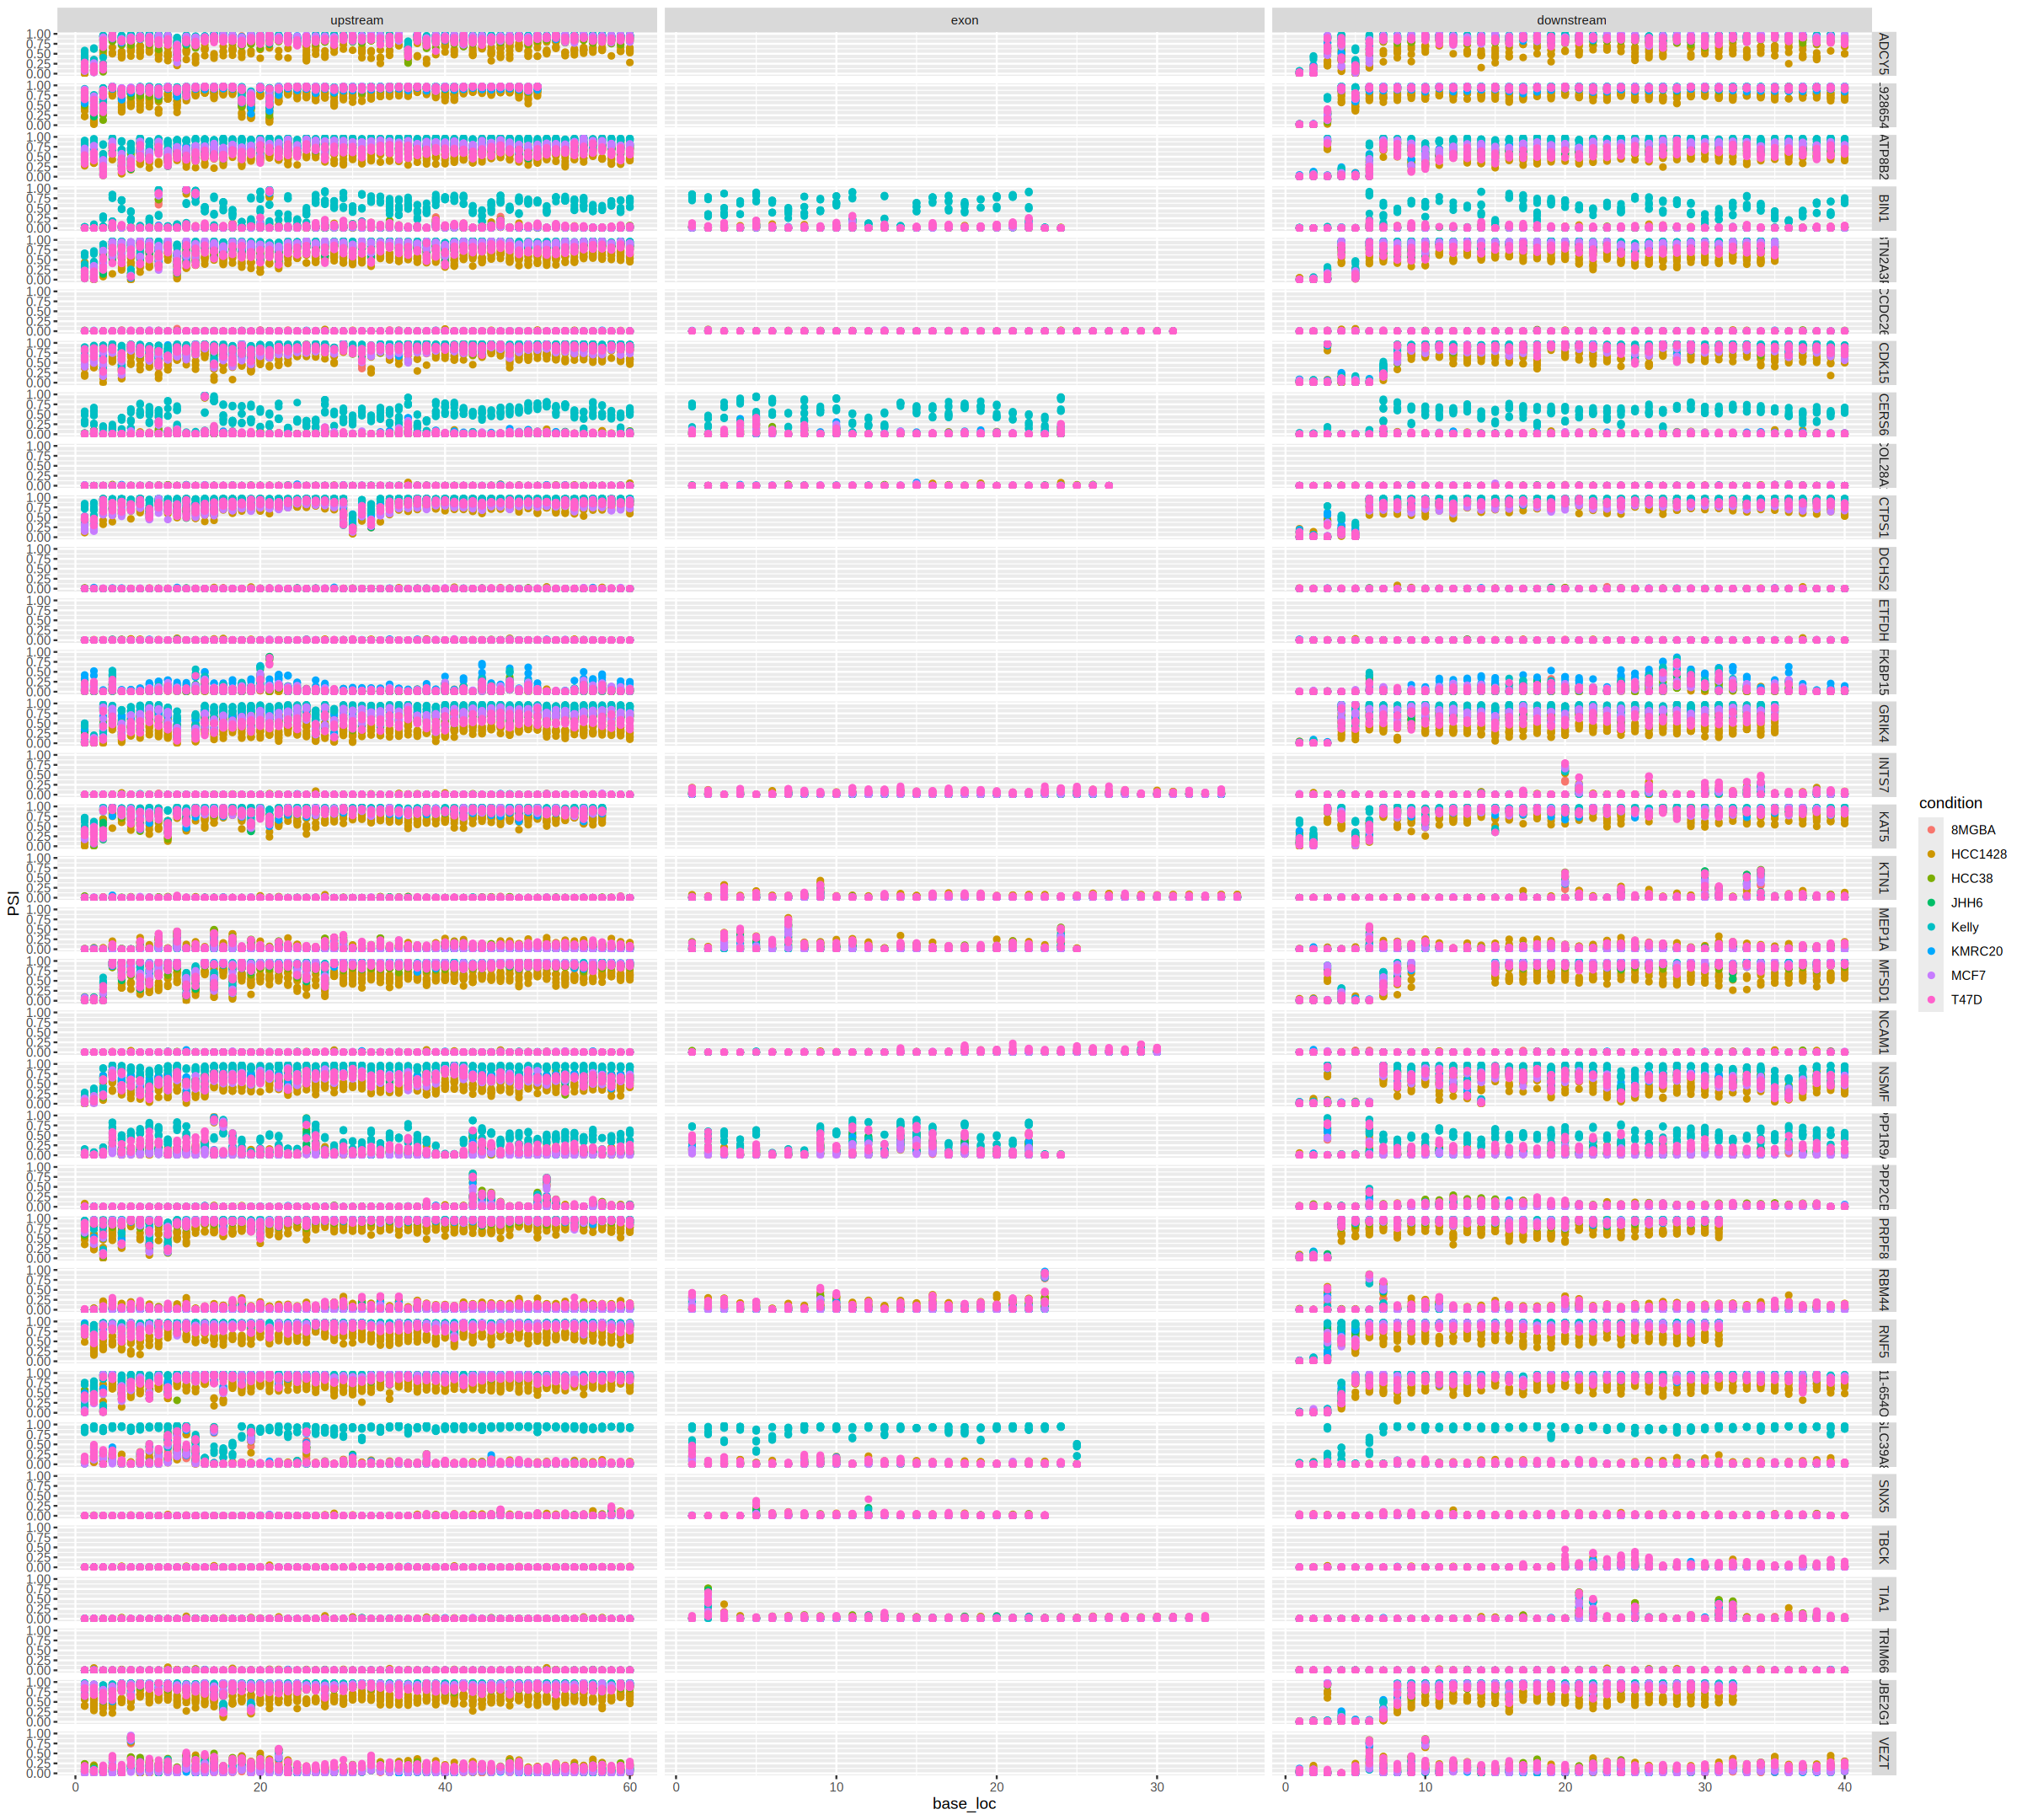

In [49]:
raw_df <- read.csv("/mnt/dawnccle2/processed_data/reprocess_250221/count_normalized_satmutv1_dawn/satmutv1_dawn_all_samples_raw_counts_satmutv1.csv")

raw_df_clean <- raw_df %>%
    mutate(index_offset = paste0(index_initial_tmp)) %>% 
    select(-filename) %>%
    filter(mode %in% c("INCLUDED", "SKIPPED")) %>% 
    group_by(sample, condition, index_offset, index, mode, offset, location, base) %>%
    summarise(count = sum(count)) %>% 
    arrange(sample, condition, index_offset)
head(raw_df_clean)

raw_df_to_psi <- raw_df_clean %>% 
    group_by(sample, condition, index_offset, index, mode, location, base) %>%
    summarise(count = sum(count)) %>% 
    ungroup() %>% 
    pivot_wider(names_from = mode, values_from = count, values_fill = 0) %>%
    mutate(total_counts = INCLUDED + SKIPPED) %>%
    filter(total_counts >= 30) %>%
    mutate(PSI  =  INCLUDED/(INCLUDED+SKIPPED)) %>% 
    mutate(base_loc = str_extract(base, "\\d+")) %>% 
    mutate(base_loc = as.numeric(base_loc))  %>% 
    mutate(location = factor(location, levels = c("upstream","exon" ,"downstream"))) %>% 
    filter(!is.na(location))
head(raw_df_to_psi)

options(repr.plot.width = 20, repr.plot.height = 18)
ggplot(raw_df_to_psi, aes(x = base_loc, y = PSI, color = condition)) +
    geom_point() +
    facet_grid(index ~ location, scale = "free_x")